In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

FIG_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5"
TAB_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Figure dir:", FIG_DIR)
print("Table dir:", TAB_DIR)

Figure dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5
Table dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5


In [ ]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

OUTPUTS_BENCHMARK_5Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_5y"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_REWARD_DIR = f"{PROJECT_ROOT}/outputs/reward_comparison"
OUTPUTS_RESULTS_DIR = f"{PROJECT_ROOT}/outputs/results_tables_figures_5y"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    OUTPUTS_BENCHMARK_5Y_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_REWARD_DIR,
    OUTPUTS_RESULTS_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

ASSETS = master_cfg["assets"]

print("OUTPUTS_RESULTS_DIR:", OUTPUTS_RESULTS_DIR)
print("ASSETS:", ASSETS)

OUTPUTS_RESULTS_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/results_tables_figures_5y
ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']


In [ ]:
# ============================================================
# CELL 04 — Load benchmark and reward comparison files
# ============================================================

benchmark_metrics_5y = pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_metrics_5y.csv")
leaderboard_test_5y = pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/leaderboard_test_5y.csv")
benchmark_interpretation_5y = pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_interpretation_5y.csv")

reward_comparison_all_5y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_all_5y.csv")

print("benchmark_metrics_5y:", benchmark_metrics_5y.shape)
print("leaderboard_test_5y:", leaderboard_test_5y.shape)
print("benchmark_interpretation_5y:", benchmark_interpretation_5y.shape)
print("reward_comparison_all_5y:", reward_comparison_all_5y.shape)

benchmark_metrics_5y: (18, 12)
leaderboard_test_5y: (6, 7)
benchmark_interpretation_5y: (3, 3)
reward_comparison_all_5y: (12, 13)


In [ ]:
# ============================================================
# CELL 05 — Load test rollout curves
# ============================================================

eq_test_rollout_5y = pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/equal_weight_rollout_test_5y.csv")
buyhold_test_rollout_5y = pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_rollout_test_5y.csv")
rand_test_rollout_5y = pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/random_policy_rollout_test_5y.csv")

mlp_test_rollout_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/mlp_ppo_5y/test_rollout_best.csv")
lstm_test_rollout_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/lstm_ppo_5y/test_rollout_best.csv")
transformer_test_rollout_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y/test_rollout_best.csv")

print("All 5Y test rollout files loaded.")

All 5Y test rollout files loaded.


In [ ]:
# ============================================================
# CELL 06 — Main results table (5Y test only)
# ============================================================

main_results_test_5y = benchmark_metrics_5y[
    benchmark_metrics_5y["split"] == "test"
][[
    "model",
    "cumulative_return",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
]].copy()

main_results_test_5y = main_results_test_5y.sort_values("cumulative_return", ascending=False).reset_index(drop=True)
main_results_test_5y["rank_test_cumret"] = np.arange(1, len(main_results_test_5y) + 1)
main_results_test_5y.to_csv(f"{TAB_DIR}/results_main_5y.csv", index=False)
display(main_results_test_5y)

,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,rank_test_cumret
0,Equal_Weight,0.250141,1.738956,-0.088813,0.000000,0.000000,1
1,BuyHold_EqualWeight,0.249163,1.680247,-0.096735,0.000000,0.000000,2
2,Transformer_PPO,0.194722,1.574676,-0.105164,0.216549,0.054354,3
3,LSTM_PPO,0.169186,1.537707,-0.091065,0.191343,0.048027,4
4,MLP_PPO,0.121174,1.420692,-0.096780,0.267925,0.067249,5
5,Random_Policy,0.000808,1.149663,-0.104923,0.631121,0.158411,6


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=main_results_test_5y)

https://docs.google.com/spreadsheets/d/1DJrQu-19VqivxiXH310bGPB8tyzL-1y53YRvtUL42xU/edit#gid=0


In [ ]:
# ============================================================
# CELL 07 — Learned-model-only comparison table (RQ1 support)
# ============================================================

learned_models = ["MLP_PPO", "LSTM_PPO", "Transformer_PPO"]

learned_results_test_5y = benchmark_metrics_5y[
    (benchmark_metrics_5y["split"] == "test") &
    (benchmark_metrics_5y["model"].isin(learned_models))
][[
    "model",
    "cumulative_return",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
]].copy()

learned_results_test_5y = learned_results_test_5y.sort_values("cumulative_return", ascending=False).reset_index(drop=True)
learned_results_test_5y["rq1_rank"] = np.arange(1, len(learned_results_test_5y) + 1)

display(learned_results_test_5y)

,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,rq1_rank
0,Transformer_PPO,0.194722,1.574676,-0.105164,0.216549,0.054354,1
1,LSTM_PPO,0.169186,1.537707,-0.091065,0.191343,0.048027,2
2,MLP_PPO,0.121174,1.420692,-0.096780,0.267925,0.067249,3


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=learned_results_test_5y)

https://docs.google.com/spreadsheets/d/1xyaGFJZkkh0xxNVxXaxVvAae4SoJuY3nh9Q39vK4my8/edit#gid=0


In [ ]:
# ============================================================
# CELL 08 — Reward comparison table (RQ2 support)
# ============================================================

rq2_results_test_5y = reward_comparison_all_5y[
    reward_comparison_all_5y["split"] == "test"
][[
    "evaluation_mode",
    "model",
    "cumulative_return",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
]].copy()

rq2_results_test_5y = rq2_results_test_5y.sort_values(["evaluation_mode", "cumulative_return"], ascending=[True, False]).reset_index(drop=True)
display(rq2_results_test_5y)

,evaluation_mode,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost
0,cost_aware_realistic,Transformer_CostAwareTrain,0.194722,1.574676,-0.105164,0.216549,0.054354
1,cost_aware_realistic,Transformer_NoCostTrain,0.189770,1.869089,-0.061448,0.178987,0.044926
2,no_cost_frictionless,Transformer_CostAwareTrain,0.261468,1.574676,-0.100794,0.216549,0.000000
3,no_cost_frictionless,Transformer_NoCostTrain,0.244447,1.869089,-0.058535,0.178987,0.000000


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=rq2_results_test_5y)

https://docs.google.com/spreadsheets/d/17wrHL3hfr2D5Wl3ArxFvGmRh-JopQ-mN8xDjkIBtLQE/edit#gid=0


In [ ]:
# ============================================================
# CELL 09 — Save tables
# ============================================================

main_results_test_5y.to_csv(f"{OUTPUTS_RESULTS_DIR}/main_results_test_5y.csv", index=False)
learned_results_test_5y.to_csv(f"{OUTPUTS_RESULTS_DIR}/learned_results_test_5y.csv", index=False)
rq2_results_test_5y.to_csv(f"{OUTPUTS_RESULTS_DIR}/rq2_results_test_5y.csv", index=False)

print("Saved 5Y results tables.")

Saved 5Y results tables.


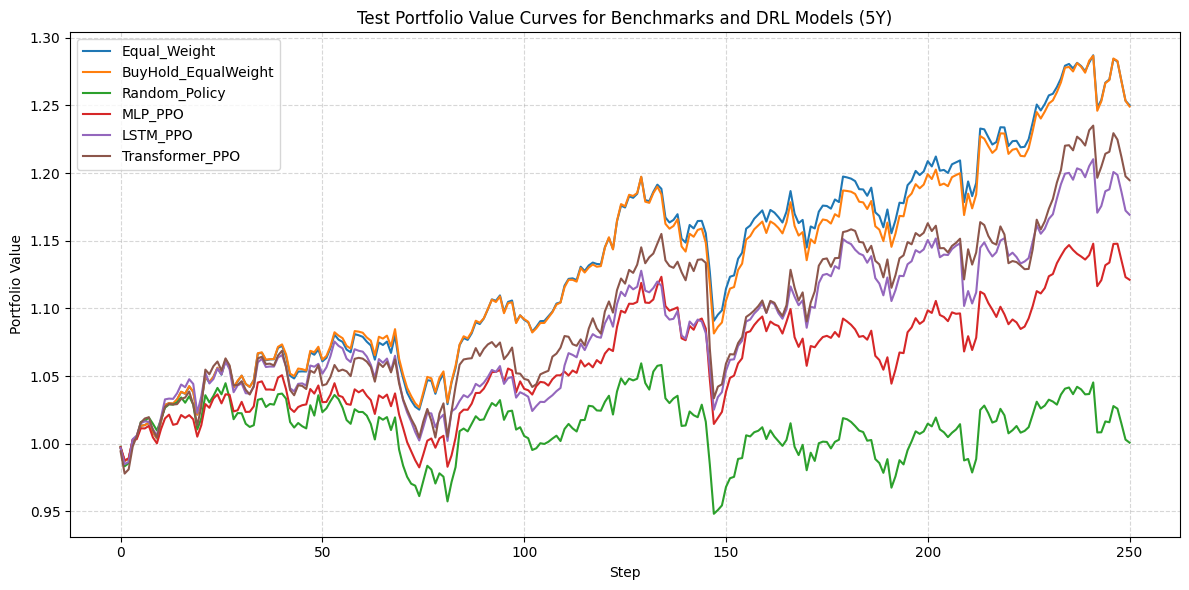

In [ ]:
# ============================================================
# CELL 10 — Figure 1: Full benchmark and model test curves (5Y)
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(eq_test_rollout_5y["portfolio_value"].values, label="Equal_Weight")
plt.plot(buyhold_test_rollout_5y["portfolio_value"].values, label="BuyHold_EqualWeight")
plt.plot(rand_test_rollout_5y["portfolio_value"].values, label="Random_Policy")
plt.plot(mlp_test_rollout_5y["portfolio_value"].values, label="MLP_PPO")
plt.plot(lstm_test_rollout_5y["portfolio_value"].values, label="LSTM_PPO")
plt.plot(transformer_test_rollout_5y["portfolio_value"].values, label="Transformer_PPO")

plt.title("Test Portfolio Value Curves for Benchmarks and DRL Models (5Y)")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/all_curves_5y.png", dpi=300, bbox_inches="tight")
plt.show()

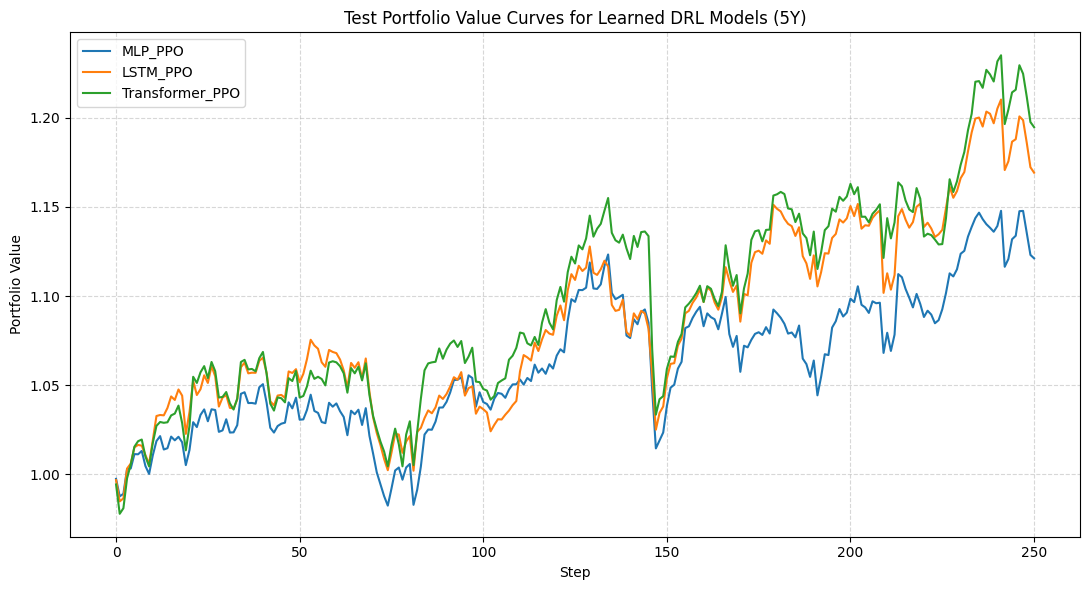

In [ ]:
# ============================================================
# CELL 11 — Figure 2: Learned-model-only test curves (5Y)
# ============================================================

plt.figure(figsize=(11, 6))
plt.plot(mlp_test_rollout_5y["portfolio_value"].values, label="MLP_PPO")
plt.plot(lstm_test_rollout_5y["portfolio_value"].values, label="LSTM_PPO")
plt.plot(transformer_test_rollout_5y["portfolio_value"].values, label="Transformer_PPO")

plt.title("Test Portfolio Value Curves for Learned DRL Models (5Y)")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/learned_curves_5y.png", dpi=300, bbox_inches="tight")
plt.show()

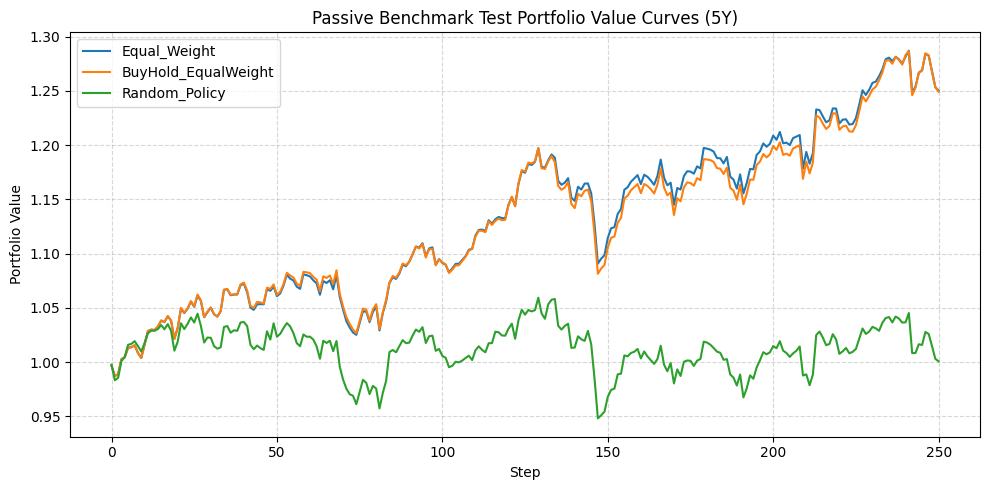

In [ ]:
# ============================================================
# CELL 12 — Figure 3: Passive benchmark comparison (5Y)
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(eq_test_rollout_5y["portfolio_value"].values, label="Equal_Weight")
plt.plot(buyhold_test_rollout_5y["portfolio_value"].values, label="BuyHold_EqualWeight")
plt.plot(rand_test_rollout_5y["portfolio_value"].values, label="Random_Policy")

plt.title("Passive Benchmark Test Portfolio Value Curves (5Y)")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/passive_curves_5y.png", dpi=300, bbox_inches="tight")
plt.show()

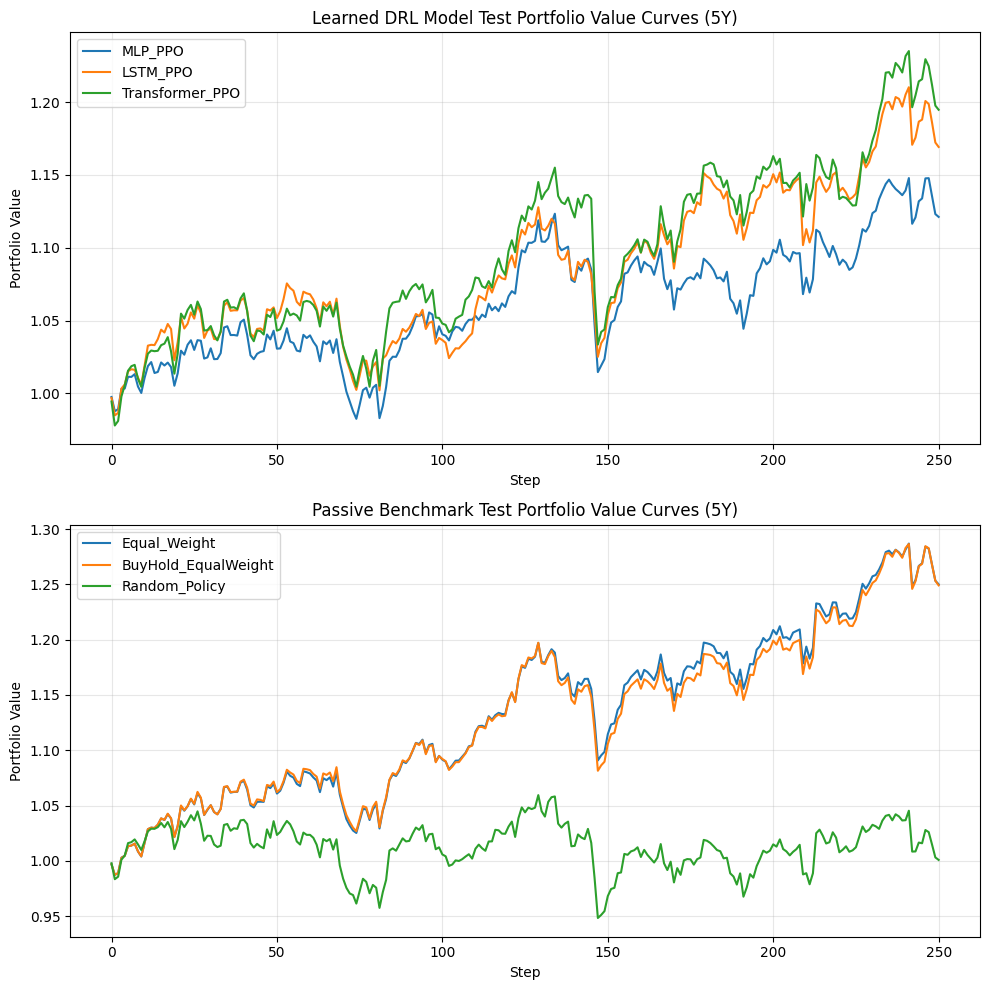

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a dictionary of portfolio_value series, using model names as keys
data_to_combine = {
    "Equal_Weight": eq_test_rollout_5y["portfolio_value"],
    "BuyHold_EqualWeight": buyhold_test_rollout_5y["portfolio_value"],
    "Random_Policy": rand_test_rollout_5y["portfolio_value"],
    "MLP_PPO": mlp_test_rollout_5y["portfolio_value"],
    "LSTM_PPO": lstm_test_rollout_5y["portfolio_value"],
    "Transformer_PPO": transformer_test_rollout_5y["portfolio_value"]
}

# Combine into a single DataFrame
portfolio_value = pd.DataFrame(data_to_combine)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel 1: learned models
ax = axes[0]
for col in ["MLP_PPO", "LSTM_PPO", "Transformer_PPO"]:
    ax.plot(portfolio_value.index, portfolio_value[col], label=col)
ax.set_title("Learned DRL Model Test Portfolio Value Curves (5Y)")
ax.set_xlabel("Step")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: passive benchmarks
ax = axes[1]
for col in ["Equal_Weight", "BuyHold_EqualWeight", "Random_Policy"]:
    ax.plot(portfolio_value.index, portfolio_value[col], label=col)
ax.set_title("Passive Benchmark Test Portfolio Value Curves (5Y)")
ax.set_xlabel("Step")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sub_curves_5y.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CELL 13 — Build findings summary table
# ============================================================

top_overall = main_results_test_5y.iloc[0]
top_learned = learned_results_test_5y.iloc[0]

findings_summary_5y = pd.DataFrame([
    {
        "topic": "RQ1",
        "finding": f"Best learned model on test was {top_learned['model']}",
        "evidence": f"Test cumulative return = {top_learned['cumulative_return']:.6f}",
    },
    {
        "topic": "RQ2",
        "finding": "Reward design changed out-of-sample performance and turnover behavior",
        "evidence": "Observed in reward comparison table for the 5Y test split",
    },
    {
        "topic": "Benchmark",
        "finding": f"Best overall test benchmark/model result was {top_overall['model']}",
        "evidence": f"Test cumulative return = {top_overall['cumulative_return']:.6f}",
    },
    {
        "topic": "Passive Baselines",
        "finding": "Equal-weight and buy-and-hold were both highly competitive passive benchmarks",
        "evidence": "Observed in the 5Y test leaderboard and passive benchmark curves",
    },
])

display(findings_summary_5y)

,topic,finding,evidence
0,RQ1,Best learned model on test was Transformer_PPO,Test cumulative return = 0.194722
1,RQ2,Reward design changed out-of-sample performanc...,Observed in reward comparison table for the 5Y...
2,Benchmark,Best overall test benchmark/model result was E...,Test cumulative return = 0.250141
3,Passive Baselines,Equal-weight and buy-and-hold were both highly...,Observed in the 5Y test leaderboard and passiv...


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=findings_summary_5y)

https://docs.google.com/spreadsheets/d/1d8dzFFygEKxy87qWL4-tCLJmrmeaArQM0NZNaZqemDM/edit#gid=0


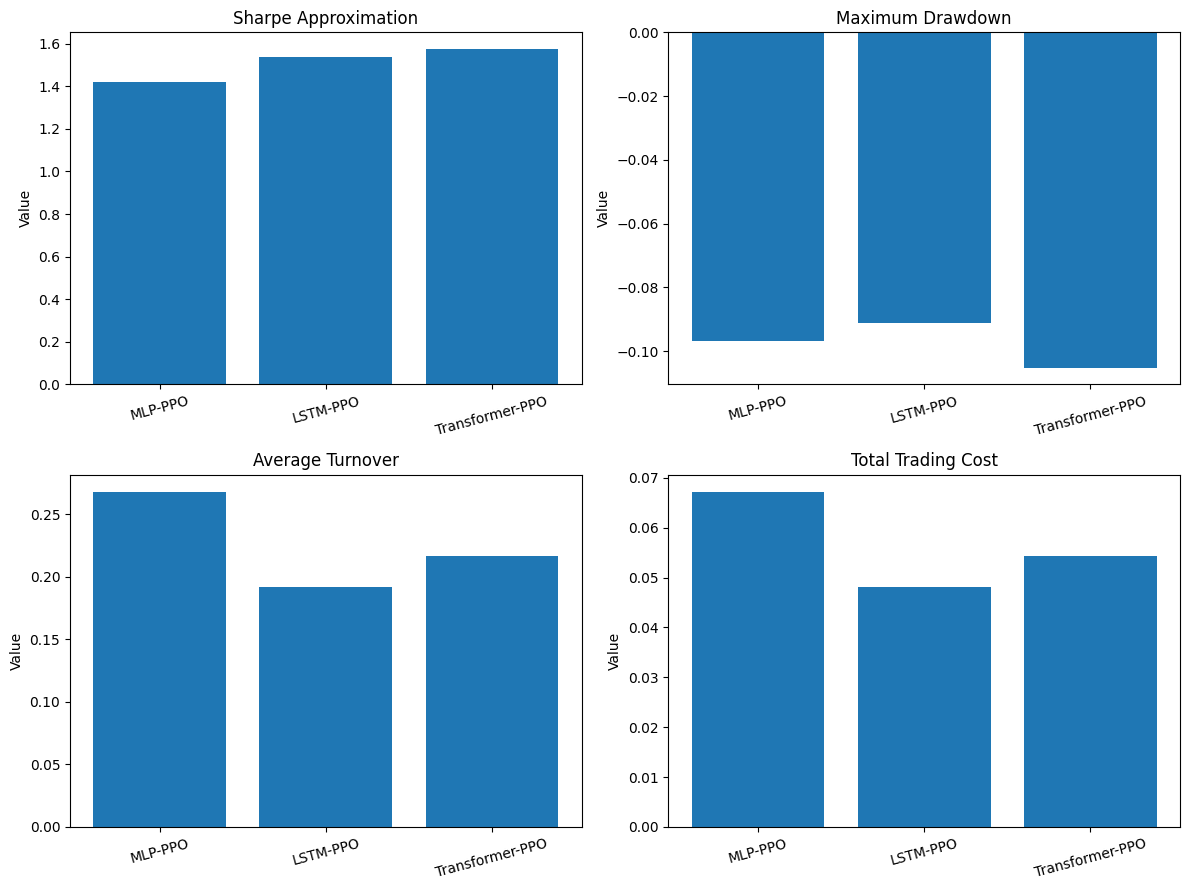

In [ ]:
# ===== Build a 4-panel learned-model metrics figure for RQ1 =====

# Expected: main results dataframe from Cell 06
# Replace main_results_test_5y with your actual dataframe name if needed.

df_rq1 = main_results_test_5y.copy()

# Keep learned models only
learned_names = ["MLP_PPO", "LSTM_PPO", "Transformer_PPO", "MLP-PPO", "LSTM-PPO", "Transformer-PPO"]
df_rq1 = df_rq1[df_rq1["model"].astype(str).isin(learned_names)].copy()

# Clean labels
label_map = {
    "MLP_PPO": "MLP-PPO",
    "LSTM_PPO": "LSTM-PPO",
    "Transformer_PPO": "Transformer-PPO",
    "MLP-PPO": "MLP-PPO",
    "LSTM-PPO": "LSTM-PPO",
    "Transformer-PPO": "Transformer-PPO",
}
df_rq1["display_label"] = df_rq1["model"].map(label_map)

order = ["MLP-PPO", "LSTM-PPO", "Transformer-PPO"]
df_rq1["display_label"] = pd.Categorical(df_rq1["display_label"], categories=order, ordered=True)
df_rq1 = df_rq1.sort_values("display_label")

required_cols = ["sharpe_approx", "max_drawdown", "avg_turnover", "total_trading_cost"]
missing = [c for c in required_cols if c not in df_rq1.columns]
if missing:
    raise ValueError(f"Missing columns in main_results_test_5y: {missing}")

labels = df_rq1["display_label"].astype(str).tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Panel 1: Sharpe
axes[0, 0].bar(labels, df_rq1["sharpe_approx"].values)
axes[0, 0].set_title("Sharpe Approximation")
axes[0, 0].set_ylabel("Value")
axes[0, 0].tick_params(axis="x", rotation=15)

# Panel 2: Maximum Drawdown
axes[0, 1].bar(labels, df_rq1["max_drawdown"].values)
axes[0, 1].set_title("Maximum Drawdown")
axes[0, 1].set_ylabel("Value")
axes[0, 1].tick_params(axis="x", rotation=15)

# Panel 3: Average Turnover
axes[1, 0].bar(labels, df_rq1["avg_turnover"].values)
axes[1, 0].set_title("Average Turnover")
axes[1, 0].set_ylabel("Value")
axes[1, 0].tick_params(axis="x", rotation=15)

# Panel 4: Total Trading Cost
axes[1, 1].bar(labels, df_rq1["total_trading_cost"].values)
axes[1, 1].set_title("Total Trading Cost")
axes[1, 1].set_ylabel("Value")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/learned_metrics_4panel_5y.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CELL 14 — Save findings summary
# ============================================================

findings_summary_5y.to_csv(f"{OUTPUTS_RESULTS_DIR}/findings_summary_5y.csv", index=False)
print("Saved:", f"{OUTPUTS_RESULTS_DIR}/findings_summary_5y.csv")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/results_tables_figures_5y/findings_summary_5y.csv


In [ ]:
# ============================================================
# CELL 15 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_RESULTS_DIR}/main_results_test_5y.csv",
    f"{OUTPUTS_RESULTS_DIR}/learned_results_test_5y.csv",
    f"{OUTPUTS_RESULTS_DIR}/rq2_results_test_5y.csv",
    f"{OUTPUTS_RESULTS_DIR}/findings_summary_5y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

print("All updated 5Y results notebook checks passed.")

All updated 5Y results notebook checks passed.
